# Identificación de factores asociados al éxito comercial de videojuegos

La tienda en línea Ice comercializa videojuegos en distintas regiones del mundo y dispone de información histórica sobre ventas, plataformas, géneros y calificaciones de usuarios y críticos. Para este proyecto se utilizará el archivo games.csv, que contiene datos de videojuegos hasta el año 2016, incluyendo variables como nombre del juego, plataforma, año de lanzamiento, género, ventas por región, calificaciones de críticos y usuarios, y clasificación ESRB.

El objetivo principal del análisis es identificar los factores que influyen en el éxito comercial de un videojuego y determinar qué características pueden ayudar a predecir el desempeño de futuros lanzamientos. Para ello, se realizará la preparación y limpieza de los datos, el análisis de ventas por plataforma, género y región, así como el estudio de la relación entre las reseñas y las ventas de los juegos.

Además, se elaborarán perfiles de usuario para diferentes regiones y se pondrán a prueba hipótesis estadísticas relacionadas con las calificaciones de los usuarios. Finalmente, los resultados permitirán identificar tendencias relevantes y proporcionar información útil para planificar campañas publicitarias durante 2017.

## Inicialización

In [2]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

## Cargar datos

In [3]:
# Cargar el archivo de datos en el DataFrame
games = pd.read_csv('/datasets/games.csv')

## Preparar los datos

En esta sección se realizará una revisión y preparación del conjunto de datos games.csv. Se examinará la estructura general del dataset, los tipos de datos de cada columna, la presencia de valores ausentes y posibles inconsistencias en los registros. Además, se realizarán las transformaciones necesarias, como la estandarización de nombres de columnas, la conversión de tipos de datos y el cálculo de las ventas globales de cada juego. Estas acciones permitirán garantizar la calidad y confiabilidad de los datos antes de llevar a cabo el análisis exploratorio y las pruebas estadísticas.

In [4]:
# Imprimir la información general/resumida sobre el DataFrame de Juegos
print("===Información general de la tabla Juegos===")
games.info()
print("===Duplicados en la tabla===")
print(games.duplicated().sum())

===Información general de la tabla Juegos===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
===Duplicados en la tabla===
0


In [5]:
# Imprimir una muestra de los datos
print("===Muestra de los datos de la tabla Juegos===")
print(games.head(5))

===Muestra de los datos de la tabla Juegos===
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  


Al revisar la información general del dataset se observa que contiene 16,715 registros y 11 columnas. No se encontraron filas duplicadas, por lo que no será necesario eliminar registros repetidos.

Los nombres de las columnas utilizan mayúsculas y minúsculas, por lo que serán estandarizados a minúsculas para facilitar su manipulación y mantener consistencia en el código.

También se identificaron valores ausentes en varias columnas. La columna year_of_release presenta 269 valores nulos, mientras que name y genre contienen 2 valores ausentes cada una. Las columnas relacionadas con las evaluaciones presentan una cantidad considerable de datos faltantes: critic_score cuenta con 8,578 valores nulos, user_score con 6,701 y rating con 6,766.

Respecto a los tipos de datos, la mayoría de las columnas tienen formatos adecuados. Sin embargo, year_of_release se encuentra como float64 aunque representa años de lanzamiento y contiene valores ausentes que deberán analizarse antes de cualquier conversión. Además, user_score aparece como tipo object, por lo que será necesario investigar sus valores para determinar si puede convertirse a un tipo numérico.

En los siguientes pasos se analizarán los valores ausentes y se realizarán las transformaciones necesarias para preparar los datos para el análisis.

### Corregir los datos

In [6]:
# Convertir los nombres de las columnas a minusculas
games.columns = games.columns.str.lower()

In [7]:
# Revisar la columna year_of_release
print(games['year_of_release'].isna().sum())

# Imprimir una muestra de los valores ausentes en year_of_release
print(games[games['year_of_release'].isna()].head(10))

269
                                            name platform  year_of_release  \
183                              Madden NFL 2004      PS2              NaN   
377                             FIFA Soccer 2004      PS2              NaN   
456                   LEGO Batman: The Videogame      Wii              NaN   
475                   wwe Smackdown vs. Raw 2006      PS2              NaN   
609                               Space Invaders     2600              NaN   
627                                    Rock Band     X360              NaN   
657     Frogger's Adventures: Temple of the Frog      GBA              NaN   
678  LEGO Indiana Jones: The Original Adventures      Wii              NaN   
719                               Call of Duty 3      Wii              NaN   
805                                    Rock Band      Wii              NaN   

         genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
183     Sports      4.26      0.26      0.01         0.71     

In [8]:
# Imprimir los valores unicos de la columna user_escore, verificar porque la columna es tipo object
print(games['user_score'].unique())

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']


In [9]:
# Reemplazar tbd por NaN
games['user_score'] = games['user_score'].replace('tbd', np.nan)
# Convertir a tipo numerico
games['user_score'] = pd.to_numeric(games['user_score'])

In [10]:

# Analizar valores ausentes de la columna name
print(games[games['name'].isna()])


      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score  user_score rating  
659           0.08           NaN         NaN    NaN  
14244         0.00           NaN         NaN    NaN  


In [11]:
# Eliminar filas con valores ausentes de la columna name
games = games.dropna(subset=['name'])
# Reempazar los NaN de la columna rating con Unknown
games['rating'] = games['rating'].fillna('Unknown')

In [12]:
# Corroboramos los cambios
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           16713 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


Como primer paso, los nombres de todas las columnas fueron convertidos a minúsculas para mantener una nomenclatura consistente y facilitar su manipulación durante el análisis.

Posteriormente se revisaron los tipos de datos de cada columna para determinar si era necesario realizar conversiones. La columna year_of_release se encuentra almacenada como float64, aunque representa años de lanzamiento. Sin embargo, esta columna contiene 269 valores ausentes, por lo que se decidió mantener su tipo de dato original para evitar la pérdida de información asociada a esos registros. Dado que la columna seguirá utilizándose únicamente como referencia temporal, no es indispensable convertirla a tipo entero.

Por otro lado, la columna user_score estaba almacenada como tipo object. Al inspeccionar sus valores se identificó la presencia de la abreviatura tbd ("to be determined"), utilizada para indicar que la calificación de usuario aún no había sido determinada. Debido a que estos valores no representan puntuaciones numéricas válidas, fueron reemplazados por valores ausentes (NaN). Después de esta corrección, la columna fue convertida a un tipo numérico (float64), permitiendo su uso en cálculos estadísticos, análisis de correlación y pruebas de hipótesis.

Respecto a los valores faltantes, se identificaron dos registros que carecían tanto de nombre (name) como de género (genre). Debido a que estos registros representan una fracción mínima del conjunto de datos y no es posible identificar correctamente los juegos correspondientes, fueron eliminados.

Los valores ausentes de critic_score y user_score se conservaron sin modificaciones. Es probable que muchos de estos juegos no hayan recibido suficientes reseñas o que la información no estuviera disponible al momento de recopilar los datos. Rellenar estas calificaciones con promedios u otros valores podría introducir sesgos en el análisis.

Por último, los valores ausentes de la columna rating fueron reemplazados por la categoría "Unknown". Esto permite distinguir entre juegos con clasificación ESRB conocida y aquellos para los que dicha información no se encuentra disponible, evitando la pérdida innecesaria de registros.

### Calcular ventas totales

Para facilitar el análisis posterior, se creará una nueva columna denominada total_sales, que representará las ventas totales de cada videojuego a nivel mundial. Este valor se obtendrá sumando las ventas registradas en Norteamérica (na_sales), Europa (eu_sales), Japón (jp_sales) y otras regiones (other_sales).

In [13]:

# Calcular ventas totales
games['total_sales'] = (
    games['na_sales']
    + games['eu_sales']
    + games['jp_sales']
    + games['other_sales']
)

# Verificar el resultado
print(games[['name', 'total_sales']].head())


                       name  total_sales
0                Wii Sports        82.54
1         Super Mario Bros.        40.24
2            Mario Kart Wii        35.52
3         Wii Sports Resort        32.77
4  Pokemon Red/Pokemon Blue        31.38


## Analizar los datos

Como primer paso del análisis exploratorio, se examinará la cantidad de videojuegos lanzados en cada año disponible en el conjunto de datos. Esto permitirá identificar períodos con mayor o menor representación de juegos y evaluar si los datos de todos los años son igualmente relevantes para el análisis.

1980.0       9
1981.0      46
1982.0      36
1983.0      17
1984.0      14
1985.0      14
1986.0      21
1987.0      16
1988.0      15
1989.0      17
1990.0      16
1991.0      41
1992.0      43
1993.0      60
1994.0     121
1995.0     219
1996.0     263
1997.0     289
1998.0     379
1999.0     338
2000.0     350
2001.0     482
2002.0     829
2003.0     775
2004.0     762
2005.0     939
2006.0    1006
2007.0    1197
2008.0    1427
2009.0    1426
2010.0    1255
2011.0    1136
2012.0     653
2013.0     544
2014.0     581
2015.0     606
2016.0     502
Name: year_of_release, dtype: int64


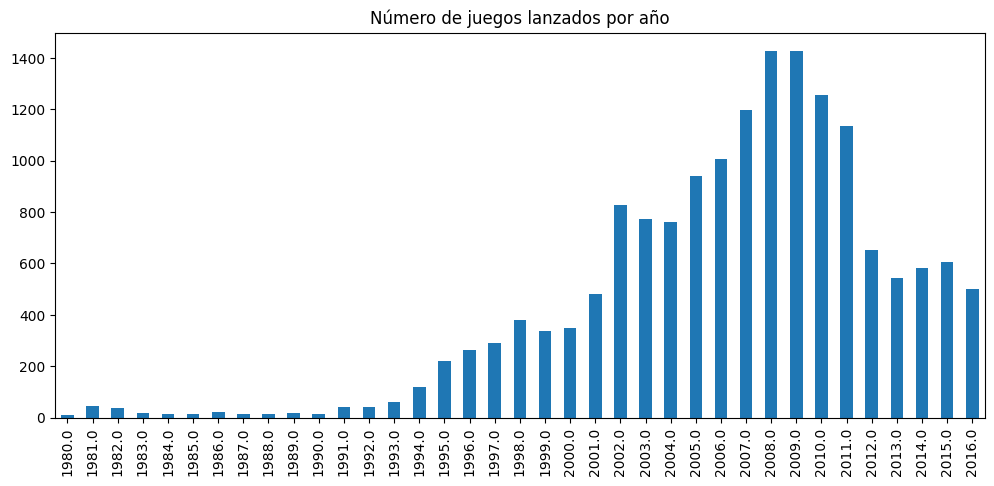

In [14]:

# Juegos lanzados por año
games_per_year = games['year_of_release'].value_counts().sort_index()

print(games_per_year)

games_per_year.plot(kind='bar',
                    figsize=(12, 5),
                    title='Número de juegos lanzados por año'
)
plt.show()


Al analizar la cantidad de videojuegos lanzados por año, se observa que los registros son escasos durante las décadas de 1980 y principios de 1990, por lo que estos períodos parecen tener una representación limitada dentro del conjunto de datos. A partir de 1995 la cantidad de lanzamientos crece de manera sostenida, alcanzando su punto máximo en 2008 y 2009 con más de 1,400 juegos registrados por año.

Después de 2010 se aprecia una disminución gradual en el número de lanzamientos. Sin embargo, esto no necesariamente implica una reducción real del mercado, ya que puede estar influenciado por la cobertura de los datos disponibles.

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
3DS      259.00
XB       257.74
GB       255.46
NES      251.05
N64      218.68
SNES     200.04
GC       198.93
XOne     159.32
2600      96.98
WiiU      82.19
PSV       54.07
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


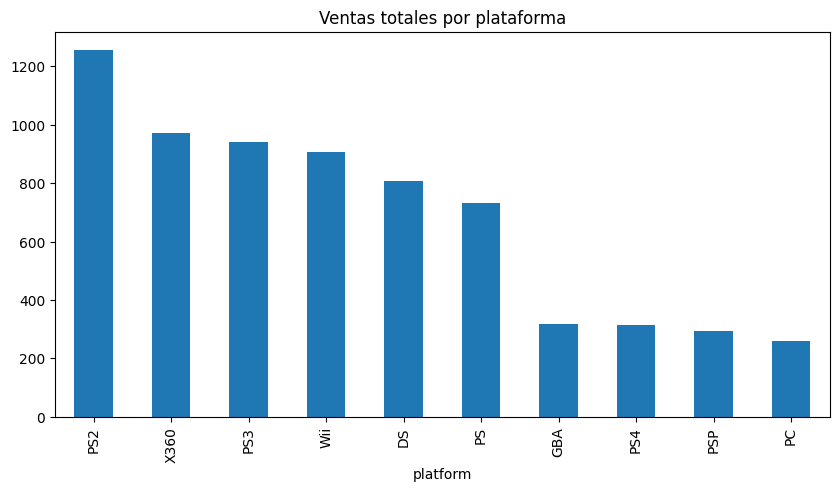

In [15]:

# Plataformas con más ventas
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print(platform_sales)

platform_sales.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Ventas totales por plataforma'
)
plt.show()


platform             DS    GBA     PC      PS     PS2     PS3     PS4    PSP  \
year_of_release                                                                
1985.0             0.02    NaN   0.04     NaN     NaN     NaN     NaN    NaN   
1988.0              NaN    NaN   0.03     NaN     NaN     NaN     NaN    NaN   
1992.0              NaN    NaN   3.03     NaN     NaN     NaN     NaN    NaN   
1994.0              NaN    NaN  12.87    6.03     NaN     NaN     NaN    NaN   
1995.0              NaN    NaN   4.22   35.96     NaN     NaN     NaN    NaN   
1996.0              NaN    NaN  10.58   94.70     NaN     NaN     NaN    NaN   
1997.0              NaN    NaN  11.27  136.17     NaN     NaN     NaN    NaN   
1998.0              NaN    NaN   3.26  169.49     NaN     NaN     NaN    NaN   
1999.0              NaN    NaN   4.74  144.53     NaN     NaN     NaN    NaN   
2000.0              NaN   0.07   4.66   96.37   39.17     NaN     NaN    NaN   
2001.0              NaN  61.53   5.47   

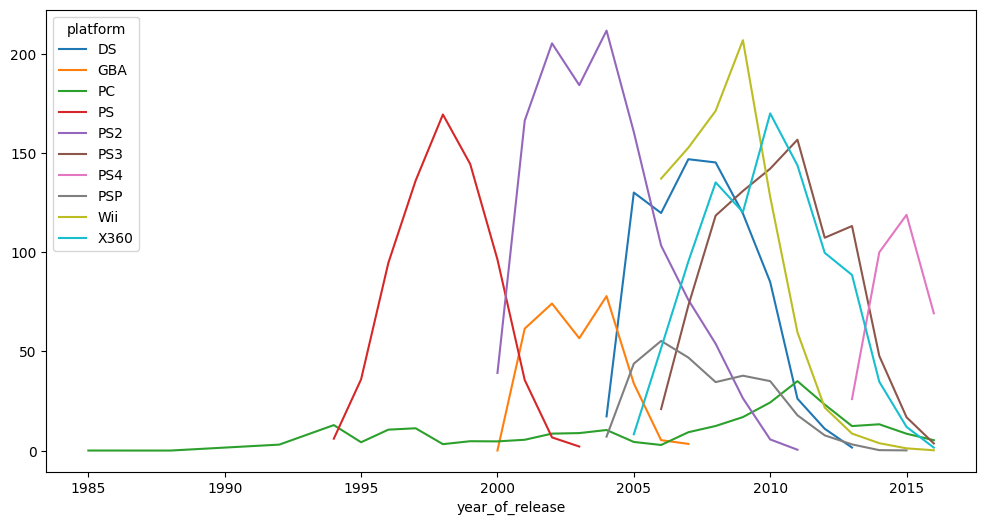

In [16]:
# Evolución de plataformas, a traves de los años.
top_platforms = platform_sales.head(10).index

platform_year_sales = games[games['platform'].isin(top_platforms)].pivot_table(index='year_of_release',columns='platform',values='total_sales',aggfunc='sum')

print(platform_year_sales)
platform_year_sales.plot(figsize=(12,6))
plt.show()

Al analizar la evolución de las plataformas a lo largo del tiempo, se observa que las ventas siguen ciclos de vida claramente definidos. Ninguna plataforma mantiene un liderazgo permanente; en su lugar, nuevas generaciones sustituyen gradualmente a las anteriores.

Plataformas como PS2, DS, Wii, PSP y X360 registraron altos niveles de ventas durante varios años, pero para 2016 habían desaparecido o mantenían una presencia mínima en el mercado. Por otro lado, plataformas más recientes como PS4 muestran una tendencia de crecimiento durante los últimos años del conjunto de datos.

Los datos sugieren que una plataforma permanece activa aproximadamente entre 8 y 12 años antes de desaparecer o perder relevancia comercial. Asimismo, las nuevas plataformas suelen requerir entre 2 y 3 años para alcanzar su etapa de mayor crecimiento y consolidarse en el mercado.

Estos resultados indican que los datos más antiguos tienen una utilidad limitada para predecir el comportamiento del mercado en 2017, ya que reflejan generaciones de plataformas que ya no se encontraban vigentes al final del período analizado.

### Seleccionar el período de análisis

Con base en el análisis anterior, se utilizarán los datos comprendidos entre 2013 y 2016 para el resto del estudio. Aunque el conjunto de datos contiene información desde 1980, gran parte de las plataformas que dominaron el mercado en décadas anteriores ya habían desaparecido o perdido relevancia para 2016.

Además, se observó que las plataformas suelen tener ciclos de vida de aproximadamente 8 a 12 años y que nuevas generaciones reemplazan gradualmente a las anteriores. Por esta razón, utilizar datos demasiado antiguos podría introducir patrones que ya no reflejan las condiciones actuales del mercado.

El período 2013-2016 incluye la transición hacia las plataformas más recientes, como PS4, y representa de manera más adecuada el mercado existente al momento de planificar estrategias para 2017. Por ello, los análisis posteriores se realizarán únicamente con los datos correspondientes a estos años.

In [18]:
# Filtrar los datos para el periodo relevante
games_actual = games[games['year_of_release'] >= 2013]

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64


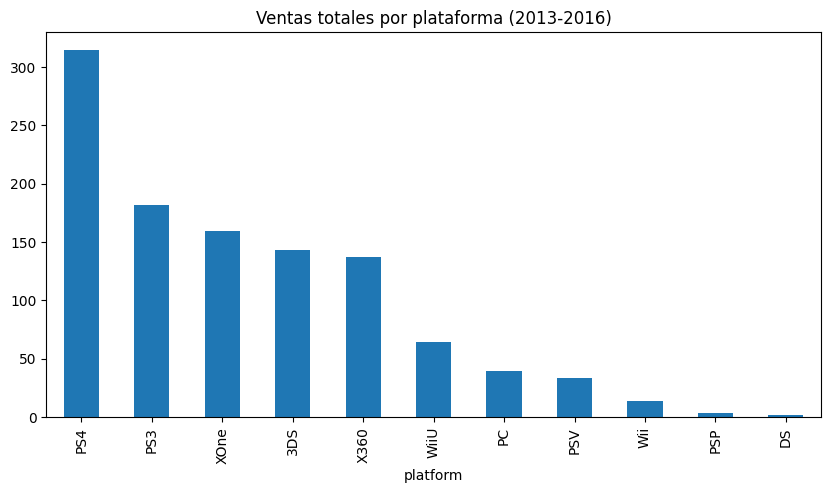

In [19]:
# Plataformas con mas ventas actuales
platform_sales_actual = (games_actual.groupby('platform')['total_sales'].sum().sort_values(ascending=False))

print(platform_sales_actual)

platform_sales_actual.plot(kind='bar',
                           figsize=(10,5),
                           title='Ventas totales por plataforma (2013-2016)'
                          )
plt.show()

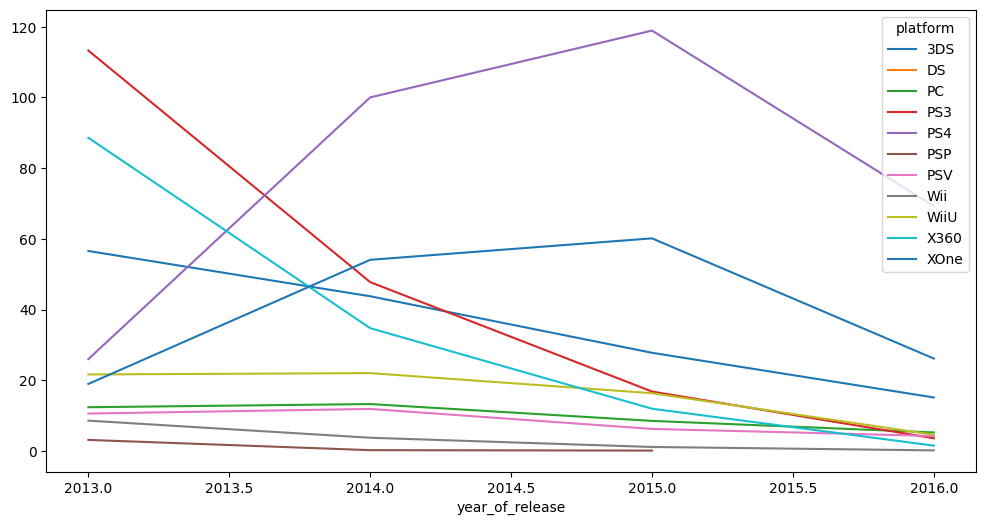

In [20]:
# Evolución de plataformas en los ultimos años.
platform_trend = games_actual.pivot_table(index='year_of_release', columns='platform', values='total_sales', aggfunc='sum')

platform_trend.plot(figsize=(12,6))
plt.show()

Al analizar las ventas acumuladas del período 2013-2016, las plataformas líderes son PS4, PS3, XOne, 3DS y X360. Sin embargo, el comportamiento de las ventas a lo largo del tiempo muestra diferencias importantes entre ellas.

PS3 y X360 presentan una disminución sostenida durante todo el período analizado, lo que indica que pertenecen a una generación de consolas que está siendo reemplazada por plataformas más recientes. De manera similar, WiiU, PSV, Wii y PSP también muestran tendencias descendentes.

Por otro lado, PS4 y XOne registran las mayores ventas entre las plataformas de nueva generación y mantienen una presencia importante en el mercado hacia el final del período analizado. Aunque los datos de 2016 pueden estar incompletos, ambas plataformas muestran un desempeño sólido en comparación con sus competidores.

La plataforma 3DS continúa generando ventas relevantes, aunque presenta una tendencia decreciente a lo largo de los años analizados.

Considerando tanto el volumen de ventas como las tendencias recientes, las plataformas con mayor potencial comercial para 2017 son PS4 y XOne. La plataforma 3DS también puede considerarse una opción interesante, aunque su comportamiento sugiere una etapa más madura dentro de su ciclo de vida.

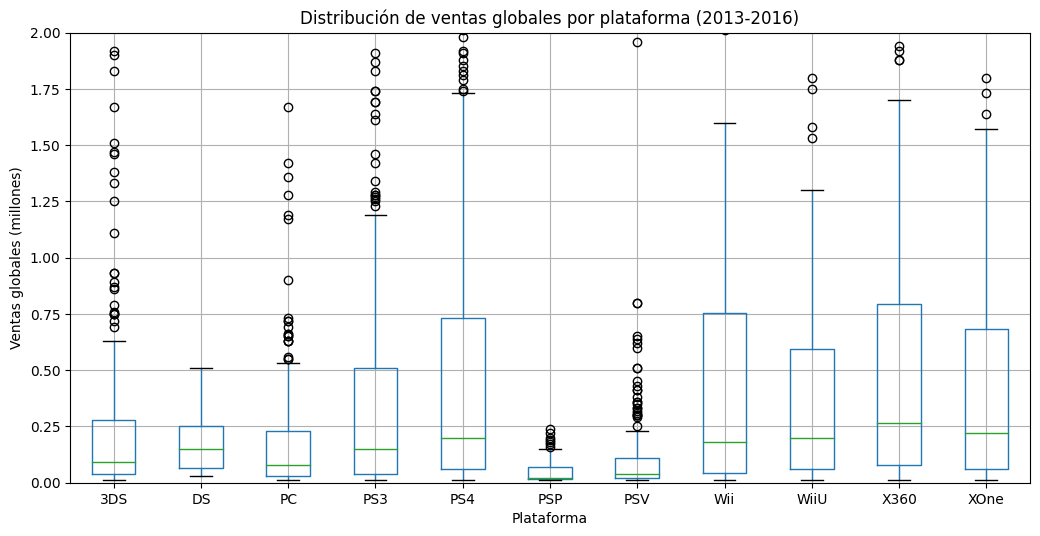

              mean  median
platform                  
PS4       0.801378   0.200
X360      0.735484   0.265
XOne      0.645020   0.220
Wii       0.593913   0.180
WiiU      0.562000   0.200
PS3       0.525884   0.150
3DS       0.472772   0.090
PC        0.208624   0.080
DS        0.192500   0.150
PSV       0.092151   0.040
PSP       0.052239   0.020


In [21]:
# Crear diagrama de caja para las ventas globales de todos los juegos
games_actual.boxplot(
    column='total_sales',
    by='platform',
    figsize=(12,6)
)

plt.ylim(0, 2)
plt.title('Distribución de ventas globales por plataforma (2013-2016)')
plt.suptitle('')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales (millones)')
plt.show()

platform_stats = games_actual.groupby('platform')['total_sales'].agg(['mean', 'median']).sort_values('mean', ascending=False)
print(platform_stats)

El diagrama de caja muestra diferencias importantes en la distribución de las ventas globales entre plataformas. Para facilitar la comparación entre la mayoría de los juegos, el eje Y se limitó a 2 millones de copias. Sin esta restricción, los valores atípicos de algunos títulos extremadamente exitosos ampliarían considerablemente la escala del gráfico, comprimiendo las cajas y dificultando la visualización de las diferencias entre plataformas. No obstante, mantener la escala completa permitiría apreciar mejor la magnitud de esos casos excepcionales.

PS4, X360 y XOne presentan los niveles de ventas más elevados, mientras que PSV y PSP registran los valores más bajos. Plataformas como PS3, Wii y WiiU muestran un desempeño intermedio.

Asimismo, se observa una gran cantidad de valores atípicos en todas las plataformas. Esto indica que algunos videojuegos alcanzan ventas excepcionalmente altas, mientras que la mayoría de los títulos obtiene resultados más modestos.

Las estadísticas descriptivas refuerzan esta observación. En casi todas las plataformas la media es considerablemente superior a la mediana, lo que evidencia una distribución sesgada hacia la derecha. En otras palabras, un pequeño número de juegos muy exitosos incrementa el promedio de ventas de cada plataforma.

En general, las plataformas PS4 y XOne destacan por combinar altos niveles de ventas y una presencia relevante en el mercado durante los años más recientes, lo que refuerza su potencial comercial de cara a 2017.

#### Influencia de las reseñas en las ventas de una plataforma popular

A continuación se analizará la relación entre las calificaciones de los críticos y de los usuarios con las ventas globales de los videojuegos. Para ello se utilizará la plataforma PS4, una de las más relevantes durante el período estudiado.

El objetivo es determinar si existe una relación entre las evaluaciones recibidas por un juego y su desempeño comercial. Para ello se emplearán gráficos de dispersión y se calcularán coeficientes de correlación entre las puntuaciones y las ventas globales.

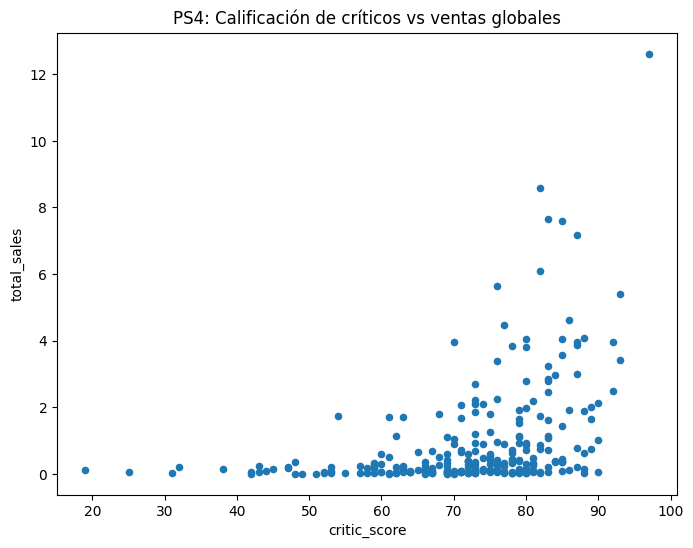

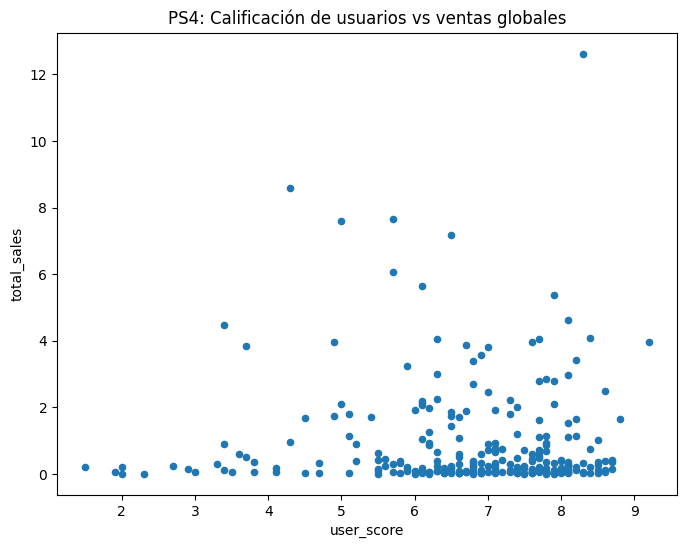

Correlación críticos-ventas: 0.40656790206178095
Correlación usuarios-ventas: -0.031957110204556376


In [22]:
# Seleccionar juegos de PS4
ps4_games = games_actual[games_actual['platform'] == 'PS4']

# Diagrama de dispersión: críticos
ps4_games.plot(kind='scatter',
               x='critic_score',
               y='total_sales',
               figsize=(8,6)
              )

plt.title('PS4: Calificación de críticos vs ventas globales')
plt.show()

# Diagrama de dispersión: usuarios
ps4_games.plot(kind='scatter',
               x='user_score',
               y='total_sales',
               figsize=(8,6)
              )

plt.title('PS4: Calificación de usuarios vs ventas globales')
plt.show()

# Correlaciones
critic_corr = ps4_games['critic_score'].corr(ps4_games['total_sales'])
user_corr = ps4_games['user_score'].corr(ps4_games['total_sales'])

print('Correlación críticos-ventas:', critic_corr)
print('Correlación usuarios-ventas:', user_corr)

Los gráficos de dispersión y los coeficientes de correlación muestran diferencias importantes entre la influencia de las reseñas de críticos y las de usuarios sobre las ventas de los juegos de PS4.

La correlación entre las calificaciones de los críticos y las ventas globales es de aproximadamente 0.41, lo que indica una relación positiva moderada. En general, los juegos que reciben mejores evaluaciones por parte de los críticos tienden a alcanzar mayores niveles de ventas, aunque esta relación no es suficientemente fuerte como para explicar por sí sola el éxito comercial de un título.

En contraste, la correlación entre las calificaciones de los usuarios y las ventas es cercana a cero (-0.03), lo que sugiere que no existe una relación lineal significativa entre ambas variables. Esto indica que una mejor valoración por parte de los usuarios no necesariamente se traduce en mayores ventas. Una posible explicación es que las decisiones de compra suelen tomarse antes de que exista un gran volumen de reseñas de usuarios, mientras que las críticas profesionales suelen estar disponibles cerca de la fecha de lanzamiento y pueden influir más directamente en la intención de compra. Además, factores como la publicidad, la popularidad de una franquicia o la exclusividad de la plataforma pueden tener un impacto mayor en las ventas que las valoraciones de los usuarios.

En conclusión, para la plataforma PS4 las reseñas de los críticos parecen tener una mayor relación con el desempeño comercial de los videojuegos que las calificaciones otorgadas por los usuarios.

In [23]:
# Juegos de PS4
ps4_names = ps4_games['name']

print(ps4_names)

31            Call of Duty: Black Ops 3
42                   Grand Theft Auto V
77                              FIFA 16
87         Star Wars Battlefront (2015)
92       Call of Duty: Advanced Warfare
                      ...              
16500                       Root Letter
16503                 Shin Hayarigami 2
16526                        Dungeons 2
16530           Carmageddon: Max Damage
16585     Farming 2017 - The Simulation
Name: name, Length: 392, dtype: object


In [24]:
# Juegos de PS4 presentes en más de una plataforma
multi_platform = games_actual[games_actual['name'].isin(ps4_names)]

# Número de plataformas por juego
platform_count = multi_platform.groupby('name')['platform'].nunique()
print(platform_count)

multi_platform_names = platform_count[platform_count > 1].index

comparison_games = multi_platform[
    multi_platform['name'].isin(multi_platform_names)
]

print(comparison_games.head())

print(comparison_games.groupby('platform')['name'].count())


name
7 Days to Die                                 2
Adventure Time: Finn & Jake Investigations    6
Aegis of Earth: Protonovus Assault            3
Agatha Christie's The ABC Murders             2
Akiba's Trip: Undead & Undressed              3
                                             ..
Yakuza: Ishin                                 2
Yoru no Nai Kuni                              3
ZombiU                                        2
Zombie Army Trilogy                           2
inFAMOUS: Second Son                          1
Name: platform, Length: 392, dtype: int64
                         name platform  year_of_release    genre  na_sales  \
16         Grand Theft Auto V      PS3           2013.0   Action      7.02   
23         Grand Theft Auto V     X360           2013.0   Action      9.66   
31  Call of Duty: Black Ops 3      PS4           2015.0  Shooter      6.03   
42         Grand Theft Auto V      PS4           2014.0   Action      3.96   
60       Call of Duty: Ghosts     X

platform
X360    0.425
PS4     0.265
PS3     0.250
XOne    0.210
PC      0.100
Name: total_sales, dtype: float64


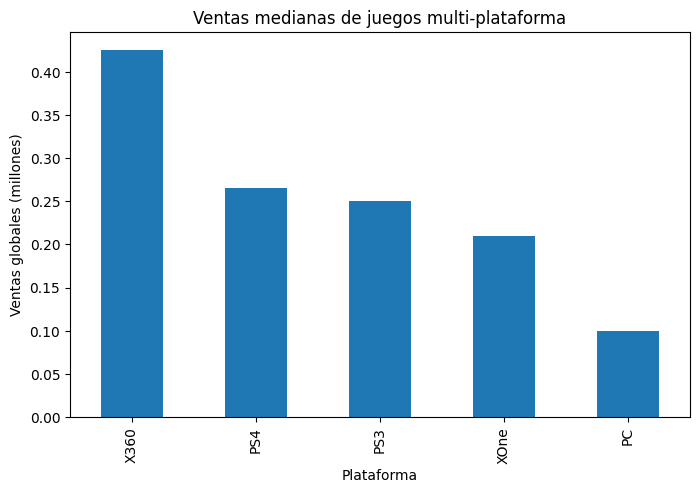

In [25]:
relevant_platforms = ['PS4', 'XOne', 'PS3', 'X360', 'PC']

comparison_sales = comparison_games[comparison_games['platform'].isin(relevant_platforms)].groupby('platform')['total_sales'].median().sort_values(ascending=False)

print(comparison_sales)

comparison_sales.plot(kind='bar',
                      figsize=(8,5),
                      title='Ventas medianas de juegos multi-plataforma'
                     )

plt.ylabel('Ventas globales (millones)')
plt.xlabel('Plataforma')
plt.show()

Al analizar los juegos que están disponibles en múltiples plataformas, se observa que el desempeño de un mismo título varía dependiendo de la plataforma en la que se publique.

Se comparan medianas porque la media es más sensible a los valores atípicos. Para hacer una comparación justa se descartaron plataformas con pocos juegos multiplataforma.

En términos de ventas medianas, la plataforma X360 presenta el mejor rendimiento entre los juegos comparables, seguida por PS4 y PS3. En cambio, PC muestra los niveles de ventas más bajos dentro del grupo analizado.

Esto sugiere que, aunque un juego sea el mismo, su éxito comercial no es idéntico en todas las plataformas. Factores como la base de usuarios de cada consola, el tipo de audiencia y la popularidad de la plataforma influyen directamente en el rendimiento de ventas.

En general, las consolas de sobremesa como X360 y PS4 tienden a generar mayores ventas para los mismos títulos en comparación con PC, lo que indica una mayor fortaleza comercial en este tipo de plataformas dentro del período analizado.

genre
Action          321.87
Shooter         232.98
Sports          150.65
Role-Playing    145.89
Misc             62.82
Platform         42.63
Racing           39.89
Fighting         35.31
Adventure        23.64
Simulation       21.76
Strategy         10.08
Puzzle            3.17
Name: total_sales, dtype: float64


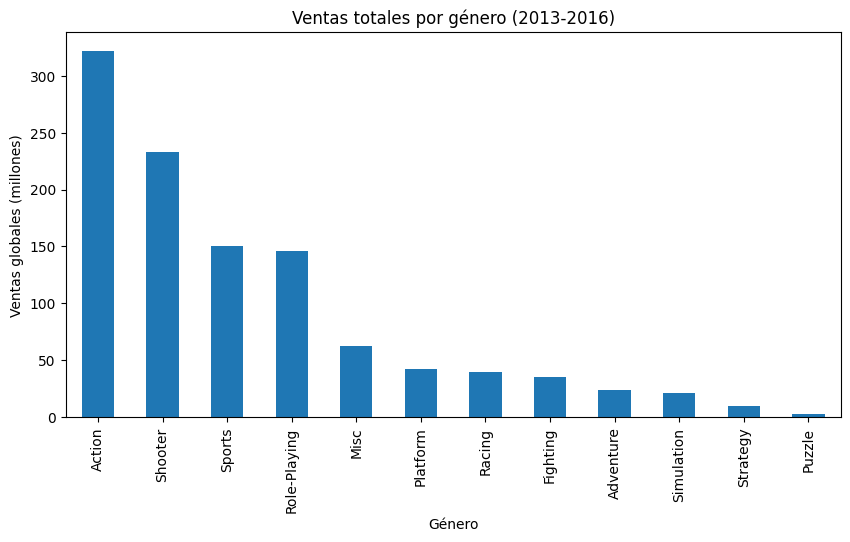

In [26]:
# Agrupar ventas totales por género y ordenarlas de mayor a menor
genre_sales = games_actual.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Mostrar resultados numéricos
print(genre_sales)

# Gráfico de barras para visualizar qué géneros generan más ingresos
genre_sales.plot(kind='bar', figsize=(10,5), title='Ventas totales por género (2013-2016)')
plt.xlabel('Género')
plt.ylabel('Ventas globales (millones)')
plt.show()

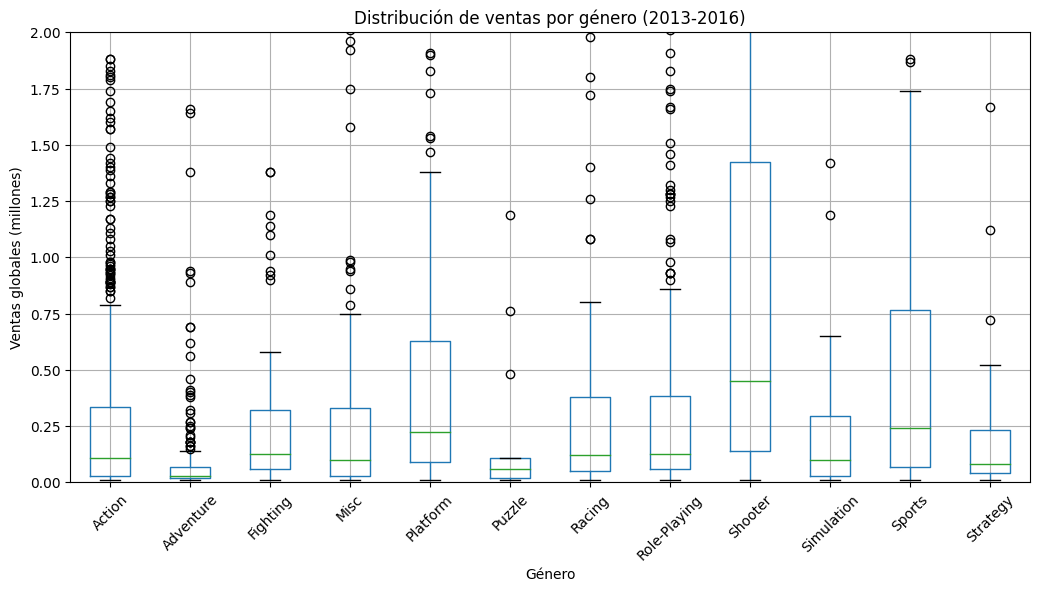

In [27]:
# Boxplot para analizar la distribución de ventas por género
# Esto permite ver no solo el total, sino también la variabilidad y valores atípicos
games_actual.boxplot(column='total_sales', by='genre', figsize=(12,6))

# Ajustes visuales del gráfico
plt.ylim(0, 2)
plt.title('Distribución de ventas por género (2013-2016)')
plt.suptitle('')  # Elimina título automático de pandas
plt.xlabel('Género')
plt.ylabel('Ventas globales (millones)')
plt.xticks(rotation=45)
plt.show()

In [28]:
# Calcular métricas clave por género:
# media (promedio), mediana y número de juegos
genre_stats = games_actual.groupby('genre')['total_sales'].agg(['mean', 'median', 'count'])

# Ordenar por promedio de ventas
genre_stats = genre_stats.sort_values('mean', ascending=False)

# Mostrar resultados
print(genre_stats)

                  mean  median  count
genre                                
Shooter       1.245882   0.450    187
Sports        0.703972   0.240    214
Platform      0.576081   0.225     74
Role-Playing  0.499623   0.125    292
Racing        0.469294   0.120     85
Fighting      0.441375   0.125     80
Action        0.420196   0.110    766
Misc          0.405290   0.100    155
Simulation    0.350968   0.100     62
Puzzle        0.186471   0.060     17
Strategy      0.180000   0.080     56
Adventure     0.096490   0.030    245



Al analizar las ventas totales por género, se observa que los géneros más rentables son Action, Shooter y Sports, los cuales concentran la mayor parte de las ventas globales en el periodo 2013–2016.

Aunque el género Action genera el mayor volumen total de ventas, esto se debe principalmente a la gran cantidad de juegos lanzados dentro del género, lo que diluye su rendimiento promedio por título.

En cambio, el género Shooter, a pesar de tener menos lanzamientos, presenta una media de ventas significativamente mayor por juego, lo que indica una mayor eficiencia comercial por título individual.

Por lo tanto, si el objetivo es maximizar ingresos por título, los géneros Shooter y Sports representan opciones más eficientes que Action.

En contraste, géneros como Puzzle, Strategy y Simulation presentan menores niveles de ventas totales. Estos géneros tienden a tener audiencias más específicas y nichos de mercado más reducidos, lo que limita su alcance comercial.


 ## Perfiles de usuario para cada región


=== TOP 5 PLATAFORMAS EN na_sales ===
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

=== TOP 5 PLATAFORMAS EN eu_sales ===
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

=== TOP 5 PLATAFORMAS EN jp_sales ===
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


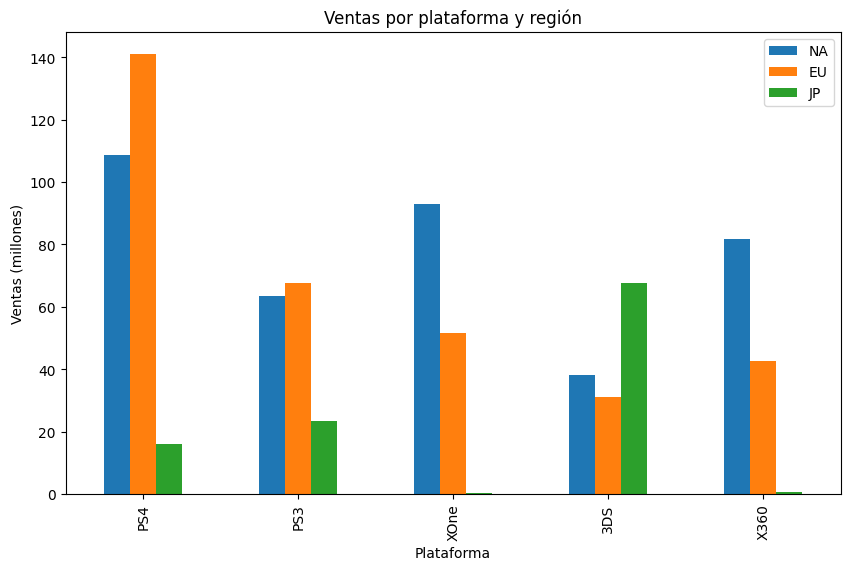

In [29]:
# Regiones a analizar
regions = ['na_sales', 'eu_sales', 'jp_sales']
platform_region = games_actual.groupby('platform')[['na_sales','eu_sales','jp_sales']].sum()

# Iteramos por cada región para obtener el Top 5 de plataformas
for region in regions:
    print("\n=== TOP 5 PLATAFORMAS EN", region, "===")
    # Ordenar de mayor a menor y mostrar las 5 principales
    print(platform_region[region].sort_values(ascending=False).head())

top_platforms = platform_region.sum(axis=1).sort_values(ascending=False).head(5).index

platform_region.loc[top_platforms].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Ventas por plataforma y región')
plt.ylabel('Ventas (millones)')
plt.xlabel('Plataforma')
plt.legend(['NA','EU','JP'])
plt.show()


=== TOP 5 GÉNEROS EN na_sales ===
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

=== TOP 5 GÉNEROS EN eu_sales ===
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

=== TOP 5 GÉNEROS EN jp_sales ===
genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64


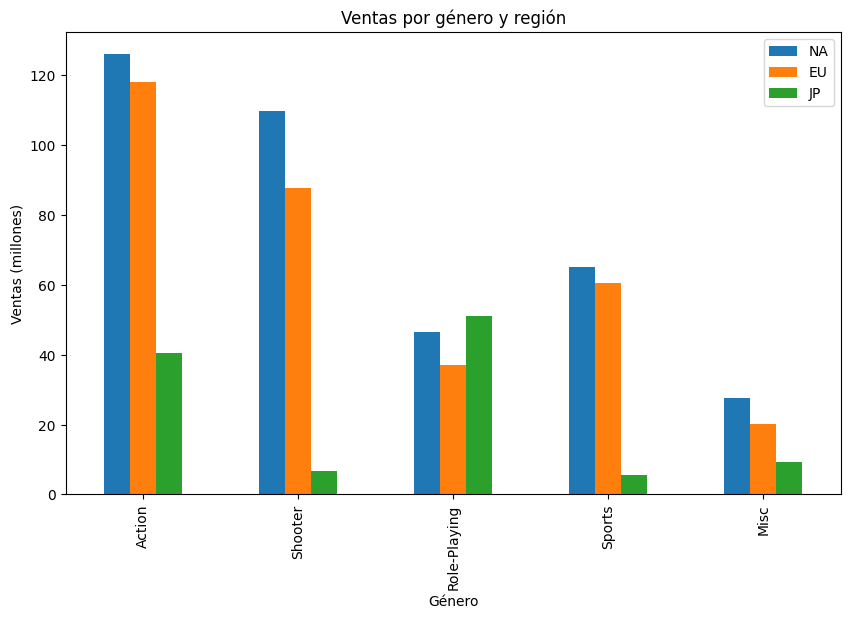

In [30]:
# Analizar distribución de géneros por región
genre_region = games_actual.groupby('genre')[['na_sales','eu_sales','jp_sales']].sum()
for region in regions:
    print("\n=== TOP 5 GÉNEROS EN", region, "===")
    # Ordenar para ver los géneros más rentables
    print(genre_region[region].sort_values(ascending=False).head())
    
top_genres  = genre_region.sum(axis=1).sort_values(ascending=False).head(5).index

genre_region.loc[top_genres].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Ventas por género y región')
plt.ylabel('Ventas (millones)')
plt.xlabel('Género')
plt.legend(['NA','EU','JP'])
plt.show()


=== ESRB vs VENTAS EN na_sales ===
rating
M          165.21
Unknown     89.42
E           79.05
E10+        54.24
T           49.79
Name: na_sales, dtype: float64

=== ESRB vs VENTAS EN eu_sales ===
rating
M          145.32
E           83.36
Unknown     78.91
E10+        42.69
T           41.95
Name: eu_sales, dtype: float64

=== ESRB vs VENTAS EN jp_sales ===
rating
Unknown    85.05
T          20.59
E          15.14
M          14.11
E10+        5.89
Name: jp_sales, dtype: float64


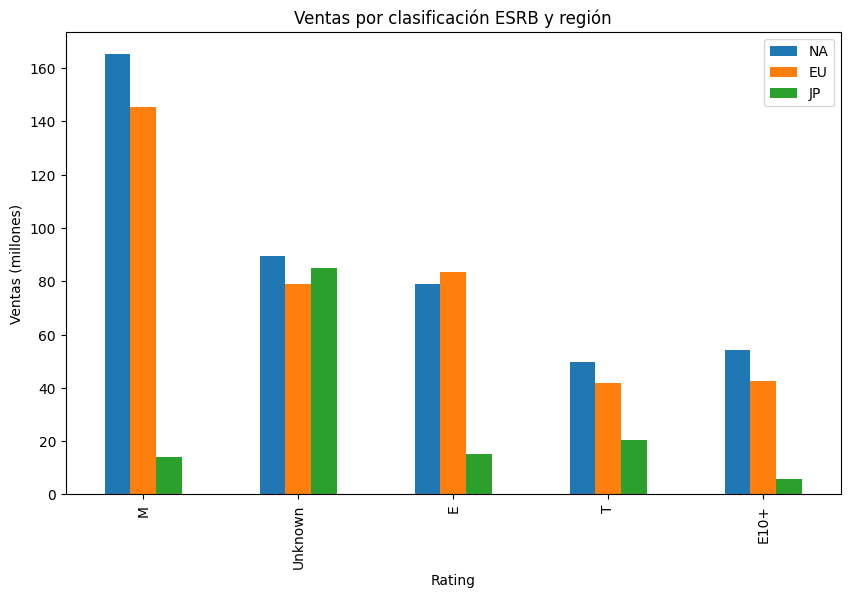

In [31]:
# Analizar si la clasificación ESRB influye en las ventas regionales
rating_region = games_actual.groupby('rating')[['na_sales','eu_sales','jp_sales']].sum()
for region in regions:
    print("\n=== ESRB vs VENTAS EN", region, "===")
    # Ordenar para identificar qué clasificaciones venden más
    print(rating_region[region].sort_values(ascending=False))
top_rating  = rating_region.sum(axis=1).sort_values(ascending=False).head(5).index

rating_region.loc[top_rating].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Ventas por clasificación ESRB y región')
plt.ylabel('Ventas (millones)')
plt.xlabel('Rating')
plt.legend(['NA','EU','JP'])
plt.show()

El análisis regional muestra que el mercado de videojuegos no es homogéneo. Cada región presenta preferencias claramente diferenciadas tanto en plataformas como en géneros y clasificación de contenido.

Norteamérica y Europa comparten patrones similares, con predominancia de juegos de acción, shooters y plataformas de sobremesa como PS4 y Xbox.
Japón presenta un comportamiento distinto, con fuerte preferencia por RPGs y consolas portátiles como 3DS.

En cuanto a la clasificación ESRB, esta influye más en los mercados occidentalizados, donde los juegos “Mature” dominan las ventas, mientras que en Japón no es tan representativo(posible falta de datos o menor adopción del sistema). Además, el mercado japonés tiende a juegos menos enfocados en contenido violento explícito.

Estos resultados indican que las estrategias de marketing deben adaptarse a cada región en lugar de aplicar un enfoque global único.

Los datos sugieren que el éxito de un videojuego depende tanto del contenido como de su adaptación cultural al mercado objetivo.

## Prueba las hipótesis estadísticas

Para evaluar las hipótesis planteadas se utilizará un nivel de significancia de: alpha = 0.05. Este valor es ampliamente utilizado en análisis estadísticos y representa una probabilidad del 5% de rechazar incorrectamente una hipótesis nula verdadera.

H0 = Las calificaciones promedio de los usuarios para Xbox One y PC son iguales.
H1 = Las calificaciones promedio de los usuarios para Xbox One y PC son diferentes.
La prueba estadística que usaremos será ttest_ind para comparar dos grupos independiente entre si

In [ ]:
# Calificaciones de usuarios para Xbox One y PC
xone_scores = games_actual[games_actual['platform'] == 'XOne']['user_score'].dropna()
pc_scores = games_actual[games_actual['platform'] == 'PC']['user_score'].dropna()

print('Varianza XOne:', xone_scores.var())
print('Varianza PC:', pc_scores.var())

if xone_scores.var() == pc_scores.var():
    print('Las varianzas son iguales')
else:
    print('Las varianzas son diferentes')

In [ ]:
# Prueba las hipótesis
alpha = 0.05
# Para el calculo equal_var=False ya que las varianzas son diferentes
results = st.ttest_ind(xone_scores , pc_scores , equal_var=False)
print('valor p:', results.pvalue)

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

print("Promedio XOne:", xone_scores.mean())
print("Promedio PC:", pc_scores.mean())

Antes de realizar la prueba de hipótesis, se compararon las varianzas de ambos grupos. Debido a que las varianzas de las calificaciones de usuarios para Xbox One (1.91) y PC (3.04) son diferentes, se utilizó la versión de Welch de la prueba t para muestras independientes (equal_var=False).

El valor p obtenido (0.1476) es mayor que el nivel de significancia de 0.05, por lo que no podemos rechazar la hipótesis nula. Esto indica que no existe evidencia estadística suficiente para afirmar que las calificaciones promedio de los usuarios para los juegos de Xbox One y PC sean diferentes.

Al observar los promedios de calificación, Xbox One presenta una puntuación media de 6.52, mientras que PC registra una media de 6.27. Aunque existe una pequeña diferencia numérica entre ambas plataformas, esta diferencia no es estadísticamente significativa y podría explicarse por la variabilidad natural de los datos.

Desde una perspectiva de negocio, este resultado sugiere que los usuarios de Xbox One y PC muestran niveles de satisfacción similares con los juegos disponibles en sus respectivas plataformas. Por lo tanto, las diferencias en el desempeño comercial entre estas plataformas probablemente estén relacionadas con otros factores, como el tamaño de la base de usuarios, las exclusividades o las estrategias de comercialización, más que con diferencias en las evaluaciones de los usuarios.

H0 = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.
H1 = Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
La prueba estadística que usaremos será ttest_ind para comparar dos grupos independiente entre si

In [ ]:
# Calificaciones de usuarios para los géneros de Acción y Deportes
action_scores = games_actual[games_actual['genre'] == 'Action']['user_score'].dropna()
sports_scores = games_actual[games_actual['genre'] == 'Sports']['user_score'].dropna()

print('Varianza Action:', action_scores.var())
print('Varianza Sports:', sports_scores.var())

if action_scores.var() == sports_scores.var():
    print('Las varianzas son iguales')
else:
    print('Las varianzas son diferentes')

In [ ]:
# Prueba las hipótesis
# Para el calculo equal_var=False ya que las varianzas son diferentes
results = st.ttest_ind(action_scores , sports_scores , equal_var=False)
print('valor p:', results.pvalue)

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


print("Promedio Action:", action_scores.mean())
print("Promedio Sports:", sports_scores.mean())


Antes de realizar la prueba de hipótesis, se compararon las varianzas de ambos grupos. Debido a que las varianzas de las calificaciones de usuarios para los géneros Action (1.77) y Sports (3.18) son diferentes, se utilizó nuevamente la versión de Welch de la prueba t para muestras independientes (equal_var=False).

El valor p obtenido (1.45 × 10⁻²⁰) es considerablemente menor que el nivel de significancia de 0.05, por lo que se rechaza la hipótesis nula. Esto indica que existe evidencia estadística suficiente para afirmar que las calificaciones promedio de los usuarios para los géneros Acción y Deportes son diferentes.

Los juegos de Acción presentan una calificación promedio de 6.84, mientras que los juegos de Deportes obtienen una media de 5.24. La diferencia entre ambos promedios es significativa tanto desde el punto de vista estadístico como práctico.

Desde una perspectiva de negocio, este resultado sugiere que los jugadores tienden a valorar mejor los juegos de Acción que los de Deportes durante el período analizado. Esto podría estar relacionado con factores como una mayor variedad de experiencias de juego, innovaciones en las mecánicas o una mejor recepción de las franquicias de Acción. Para la planificación de campañas publicitarias o futuras inversiones, los juegos de Acción podrían representar una categoría con mayor aceptación entre los usuarios.

## Conclusión general
En este proyecto se analizaron los datos históricos de ventas de videojuegos con el objetivo de identificar los factores asociados al éxito comercial de un título y obtener información útil para planificar campañas publicitarias en 2017.

1. Durante la preparación de los datos se corrigieron tipos de datos, se trataron valores ausentes y se creó una variable de ventas globales (total_sales). Los valores faltantes en las calificaciones se mantuvieron para evitar introducir sesgos en el análisis.

2. El análisis histórico mostró que las plataformas tienen ciclos de vida limitados, generalmente entre 8 y 12 años. Debido a ello, se decidió trabajar únicamente con los datos de 2013-2016, ya que representan mejor las condiciones del mercado cercanas a 2017. Las plataformas con mejores perspectivas fueron PS4 y XOne, mientras que PS3 y X360 mostraban señales de declive.

3. Las reseñas de los críticos presentaron una correlación positiva moderada con las ventas de los juegos en PS4 (≈0.41), mientras que las calificaciones de los usuarios prácticamente no mostraron relación con las ventas. Esto sugiere que factores como la recepción crítica, la publicidad y la popularidad de una franquicia pueden influir más en el desempeño comercial que las valoraciones de los usuarios.

4. Entre los géneros analizados, Action generó las mayores ventas totales debido a la gran cantidad de títulos publicados. Sin embargo, Shooter presentó el mayor promedio de ventas por juego, lo que indica una mayor rentabilidad por título. En contraste, géneros como Puzzle, Strategy y Adventure mostraron niveles de ventas considerablemente menores.

5. El análisis regional mostró diferencias importantes entre mercados. Norteamérica y Europa comparten preferencias similares, dominadas por PS4, Xbox, Action y Shooter. Japón presenta un comportamiento distinto, con una fuerte preferencia por los juegos de Role-Playing y la plataforma 3DS. Esto indica que las estrategias de marketing deben adaptarse a cada región.

6. Las pruebas de hipótesis mostraron que no existen diferencias estadísticamente significativas entre las calificaciones promedio de usuarios para Xbox One y PC (p = 0.1476). En cambio, sí se encontraron diferencias significativas entre las calificaciones de los géneros Action y Sports (p < 0.05), siendo los juegos de Acción mejor valorados por los usuarios.

En conclusión, los datos sugieren que para maximizar las probabilidades de éxito en 2017 conviene priorizar plataformas como PS4 y XOne, enfocarse en géneros con buen desempeño comercial como Shooter y Action, y adaptar las campañas publicitarias a las preferencias de cada región. Además, las reseñas de los críticos parecen ser un indicador más útil del potencial de ventas que las calificaciones de los usuarios.